# Voting Classifiers and Bagging and Pasting

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "ensembles"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## Voting Classfiers

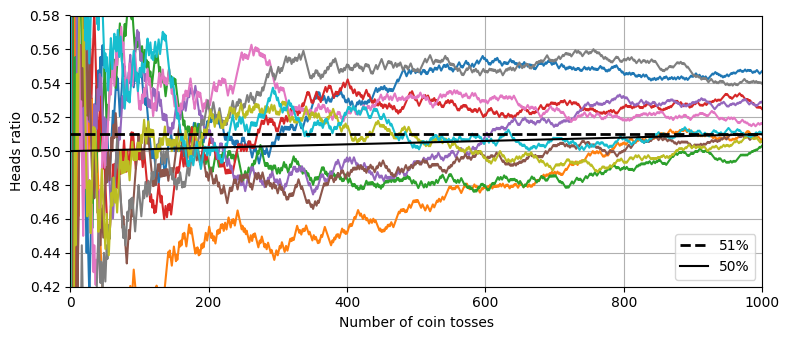

In [3]:
head_proba = 0.51
np.random.seed(42)
coin_tosses = (np.random.rand(10000, 10) < head_proba).astype(np.int32)
cumulative_heads = coin_tosses.cumsum(axis = 0)
cumulative_heads_ratio =  cumulative_heads / np.arange(1, 10001).reshape(-1,1)

plt.figure(figsize=(8, 3.5))
plt.plot(cumulative_heads_ratio)
plt.plot([0, 10000], [0.51, 0.51], "k--", linewidth = 2, label = "51%")
plt.plot([0, 1000], [0.5, 0.51], "k-", label = "50%")
plt.xlabel("Number of coin tosses")
plt.ylabel("Heads ratio")
plt.legend(loc = "lower right")
plt.axis([0, 1000, 0.42, 0.58])
plt.grid()
save_fig("law_of_large_numbers_plot")

In [4]:
X, y = make_moons(n_samples = 500, noise = 0.30, random_state = 42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

voting_clf = VotingClassifier(
    estimators = [
        ('lr', LogisticRegression(random_state = 42)),
        ('rf', RandomForestClassifier(random_state = 42)),
        ('svc', SVC(random_state = 42))
    ]
)
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(random_state=42))])

In [5]:
for name, clf in voting_clf.named_estimators_.items():
    print(name, "=", clf.score(X_test, y_test))

lr = 0.864
rf = 0.896
svc = 0.896


In [6]:
voting_clf.predict(X_test[:1])

array([1], dtype=int64)

In [7]:
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([1], dtype=int64), array([1], dtype=int64), array([0], dtype=int64)]

In [8]:
voting_clf.score(X_test , y_test)

0.912

In [9]:
voting_clf.voting = "soft"
voting_clf.named_estimators["svc"].probability = True
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

0.92

## Bagging and Pasting

In [10]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators= 500,
                           max_samples = 100, n_jobs =- 1, random_state = 42)
bag_clf.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=100,
                  n_estimators=500, n_jobs=-1, random_state=42)

In [11]:
def plot_decision_boundary(clf, x, y, alpha=1.0):
    axes = [-1.5, 2.4, -1, 1.5]
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                        np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha = 0.3*alpha, cmap = 'Wistia')
    plt.contour(x1, x2, y_pred, cmap = 'Greys', alpha = 0.8 * alpha)
    colors = ['#78785c', "#c47b27"]
    markers = ("o", "^")
    for idx in (0,1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                color = colors[idx], marker = markers[idx], linestyle = "None")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation = 0)

In [12]:
tree_clf = DecisionTreeClassifier(random_state= 42)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

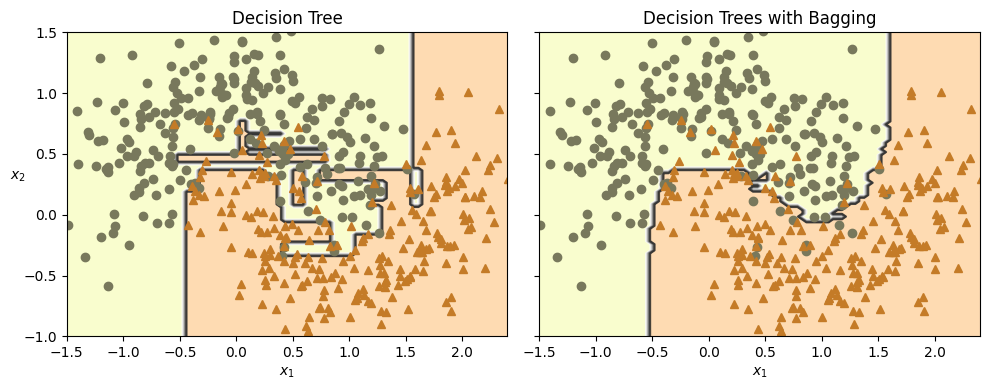

In [13]:
fig,axes = plt.subplots(ncols = 2, figsize = (10,4), sharey = True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf, X, y)
plt.title("Decision Tree")

plt.sca(axes[1])
plot_decision_boundary(bag_clf, X, y)
plt.title("Decision Trees with Bagging")
plt.ylabel("")
save_fig("decision_tree_without_and_with_bagging_plot")

## Out og Bag evaluation

In [14]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators = 500,
                           oob_score =  True, n_jobs = -1, random_state =42)

bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.896

In [15]:
bag_clf.oob_decision_function_[:3] # probas for the first 3 instances

array([[0.32352941, 0.67647059],
       [0.3375    , 0.6625    ],
       [1.        , 0.        ]])

In [16]:
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.92

##### If you randomly draw one instance from a dataset of size m, each instance in the dataset obviously has probability 1/m of getting picked, and therefore it has a probability 1 – 1/m of not getting picked. If you draw m instances with replacement, all draws are independent and therefore each instance has a probability (1 – 1/m)m of not getting picked. Now let's use the fact that exp(x) is equal to the limit of (1 + x/m)m as m approaches infinity. So if m is large, the ratio of out-of-bag instances will be about exp(–1) ≈ 0.37. So roughly 63% (1 – 0.37) will be sampled.

In [17]:
# extra code – shows how to compute the 63% proba
print(1 - (1 - 1 / 1000) ** 1000)
print(1 - np.exp(-1))

0.6323045752290363
0.6321205588285577
